In [7]:
import pandas as pd
import numpy as np
data = pd.read_csv("../content/Data.csv")

data = data.drop(columns=["VD", "VE", "tempo"])

data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data = data.rename(columns={
    "Setpoint VD": "Wd",
    "Setpoint VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"
colors = ['green', 'blue', 'orange', 'red', 'black',]


def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Wd e We como linhas
    for preds in PREDICTORS:
        sns.lineplot(x=df.index, y=df[preds], ax=ax1, marker="o", label=preds,  linewidth=2)

    if PlotOut:
        ax2 = ax1.twinx()
        sns.lineplot(x=df.index, y=df[TARGET], ax=ax2, marker="o", label=TARGET, color="orange", linestyle="dashed", linewidth=2)
        ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")

    # plt.xticks(df.index[::10], rotation=45, fontsize=1)  

    # Adicionando legendas
    ax1.legend(loc="upper left")
    if PlotOut:
        ax2.legend(loc="upper right")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)

    # Salvando o gráfico
    plt.savefig(f"content/{img_name}", format="svg", dpi=600)

    # Exibindo o gráfico
    plt.show()


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

class PrepareData:
    def __init__(self, Dataset):
        self.df = Dataset.copy()
        self.scaler = StandardScaler()
        self.df[PREDICTORS] = self.scaler.fit_transform(self.df[PREDICTORS])
    
    def GetData(self, size=1000):
        df = self.df.head(size)
        PlotTimeSeries(df = df)
        
        # Split into train (70%), validation (15%), and test (15%) sets
        train_data, temp_data = train_test_split(df, test_size=0.3, shuffle=False)
        valid_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)
            
        x_train = train_data[PREDICTORS].to_numpy()
        y_train = train_data[[TARGET]].to_numpy()

        x_val = valid_data[PREDICTORS].to_numpy()
        y_val = valid_data[[TARGET]].to_numpy()
        
        x_test = test_data[PREDICTORS].to_numpy()
        y_test = test_data[[TARGET]].to_numpy()
        
        x_sup = df[PREDICTORS]
        y_sup = df[TARGET]
        
        return x_train, y_train, x_val, y_val, x_test, y_test, x_sup, y_sup

In [3]:
from keras import layers, regularizers, Sequential, initializers, optimizers
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error

class ShuffleArchitecture:
    def __init__(self, input_shape, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_shape = input_shape
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))
    
    def CreateModel(self):
        model = Sequential()
        model.add(layers.Input(shape=self.input_shape))  # input layer

        for size in self.hidden_sizes:  # hidden layers
            model.add(layers.SimpleRNN(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                            return_sequences=False,
                        ))

        model.add(layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer
        return (model)

2025-04-07 18:58:00.819842: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-07 18:58:01.706254: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-07 18:58:04.640785: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744052289.451370    2826 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744052289.629986    2826 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-07 18:58:12.728345: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [4]:
from itertools import product
   
class TrainWithSmallDataset:
    def __init__(self, Dataset,  run_times=500, dataset_run_times=10):
        DataHandler = PrepareData(Dataset=Dataset)
        
        self.x_train, self.y_train, self.x_val, self.y_val, self.x_test, self.y_test, self.x_sup, self.y_sup = DataHandler.GetData()
        self.better_metrics = {}
        self.run_times = run_times
        self.dataset_run_times = dataset_run_times

            
    def CompileModel(self, model, lr, epochs=100):
        model.compile(loss="mse",
                      optimizer=optimizers.Adam(learning_rate=lr))

        early_stop = EarlyStopping(monitor='val_loss',
                                   patience=10,
                                   restore_best_weights=True)

        self.history = model.fit(
            self.x_train, self.y_train,
            epochs=epochs,
            validation_data=(self.x_val, self.y_val),
            callbacks=[early_stop],
            verbose=False
        )
        
    def ComputeMetrics(self):
          # Calculando a saida com os dados normalizados
          train_pred = self.model.predict(self.x_train)
          test_pred = self.model.predict(self.x_test)
          val_pred = self.model.predict(self.x_val)
          sup_pred = self.model.predict(self.x_sup)

          metrics = {
                          'r2': r2_score(self.y_train, train_pred),
                          'r2_sup': r2_score(self.y_sup,  sup_pred),
                          'r2_test': r2_score(self.y_test, test_pred),
                          'r2_val': r2_score(self.y_val, val_pred),
                          'mse': mean_squared_error(self.y_train, train_pred),
                          'mse_sup':  mean_squared_error(self.y_sup,  sup_pred),
                          'mse_test': mean_squared_error(self.y_test, test_pred),
                          'mse_val': mean_squared_error(self.y_val, val_pred),
          }
          self.PlotPredictions()
          return(metrics)
      
    def SaveModelWeights(self, model, fileName):
        path = f"./content/models/{fileName}.weights.h5"
        open(path,'w').close()
        model.save_weights(path)   
    
    def SetArchitecure(self, _hidden_sizes, _pg):
        shuffler = ShuffleArchitecture(input_shape=(2, 1),
                                        hidden_sizes=_hidden_sizes,
                                        output_size=1,
                                        act_h='tanh',
                                        act_o='sigmoid',
                                        param_reg=_pg)
        model = shuffler.CreateModel()
        return(model)
        
    def LoopWeights(self, sort_by, boundarie, lr, idx):
        better_model = 0
        save = False

        for i in range(self.run_times):
            print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
            self.CompileModel(self.model, lr, epochs=100)
            metrics = self.ComputeMetrics()
            
            if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
                fileName = f"model_{idx}_{better_model}"
                self.SaveModelWeights(self.model, fileName)
                self.better_metrics[fileName] = metrics
                better_model += 1
                save = True
        return(save)

    def Evaluate(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate): 
                 
        for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
            header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
            print(f"Testando combinacao{count}: {header}")
            
            self.model = self.SetArchitecure(hidden_size, reg)
            
            if (self.LoopWeights(sort_by, boundarie, lr, f"{count}") == True):
                self.DisplayBetterResults('mse_sup', header, f"{count}")
        self.better_metrics = {}

    def DisplayBetterResults(self, sort_by, header, dataset=0):
        df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
        df = df.sort_values([sort_by])
        display(df)
        path = f'./results/metrics_{dataset}'
        df.to_excel(f"{path}.xlsx", index=True)
        print(f"DataFrame salvo em {path}")
        with open(f"{path}.txt", 'w') as arquivo:
            arquivo.write(header)
            
    def PlotPredictions(self):
        sets = {
            "Train": (self.x_train, self.y_train),
            "Validation": (self.x_val, self.y_val),
            "Test": (self.x_test, self.y_test),
            "Supervision": (self.x_sup, self.y_sup)
        }

        for name, (x, y_true) in sets.items():
            y_pred = self.model.predict(x)

            plt.figure(figsize=(8, 4))
            plt.plot(y_true, label='Original', marker='o')
            plt.plot(y_pred, label='Predição', marker='x')
            plt.title(f'{name} Set: Original vs Predito')
            plt.xlabel('Amostra')
            plt.ylabel('Valor')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
       
        

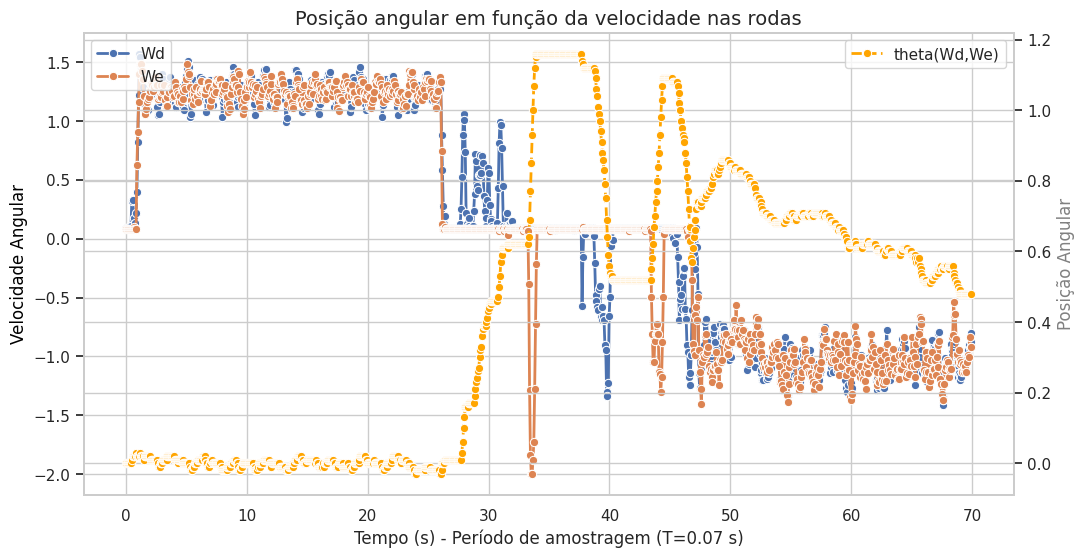

Testando combinacao1: Hidden Size=[2], regularizer=0.02, learning_rate=0.01


2025-04-07 18:59:27.770652: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


+++++++++++ [1] | 1 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


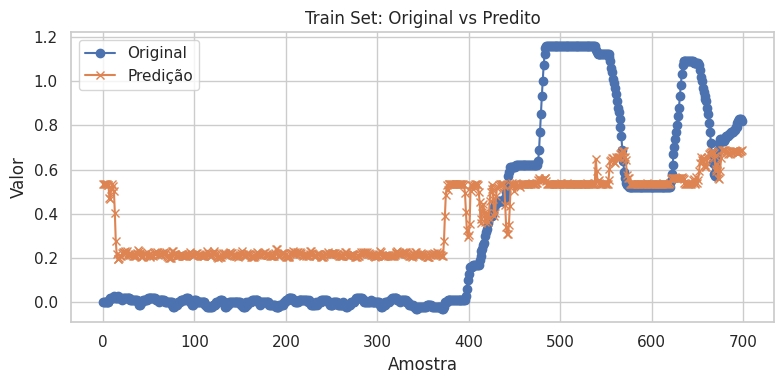

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


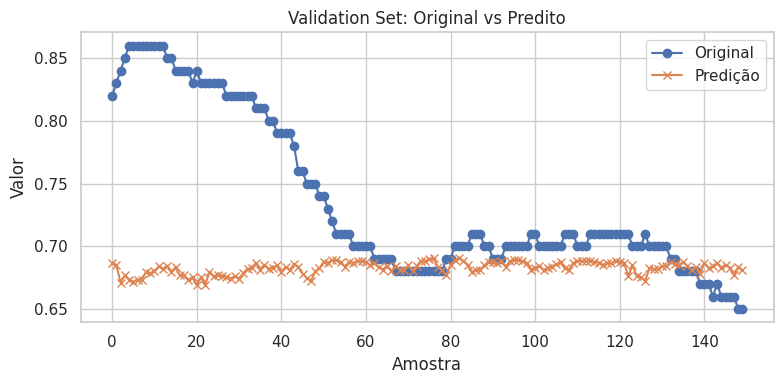

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


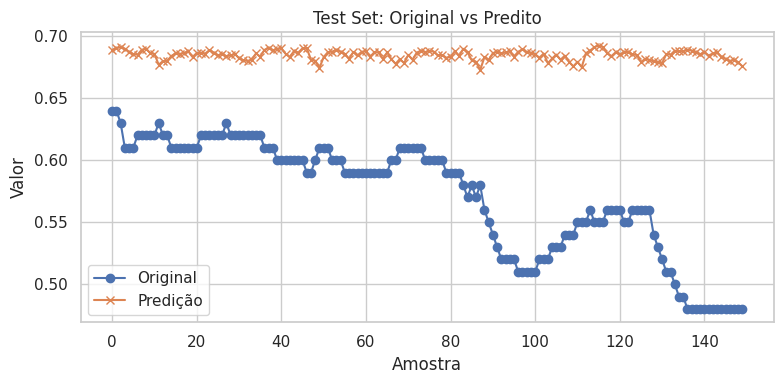

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


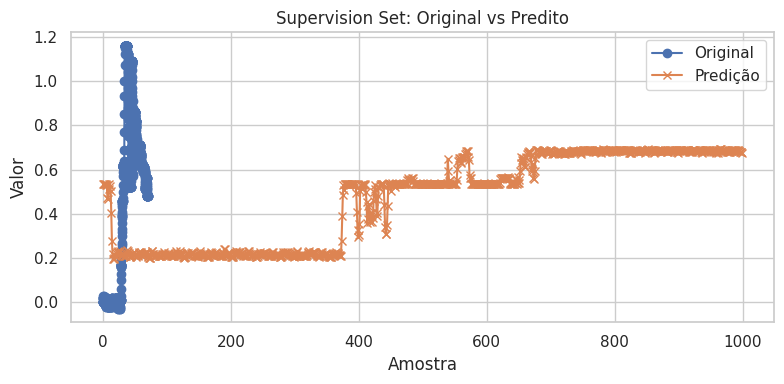

+++++++++++ [1] | 2 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


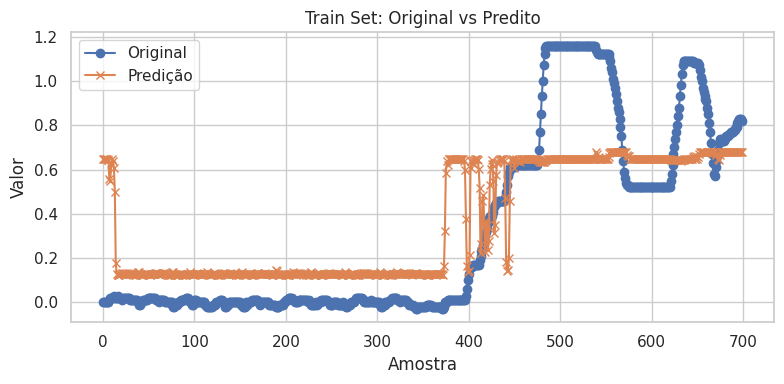

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


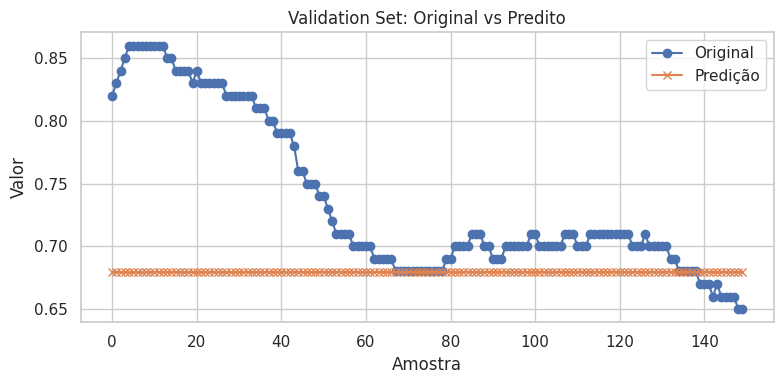

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


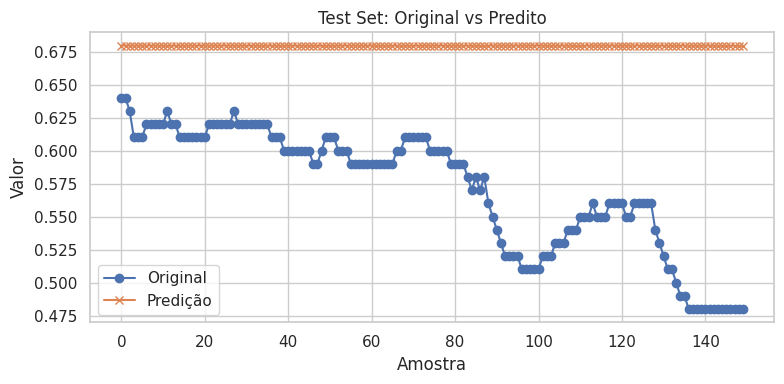

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


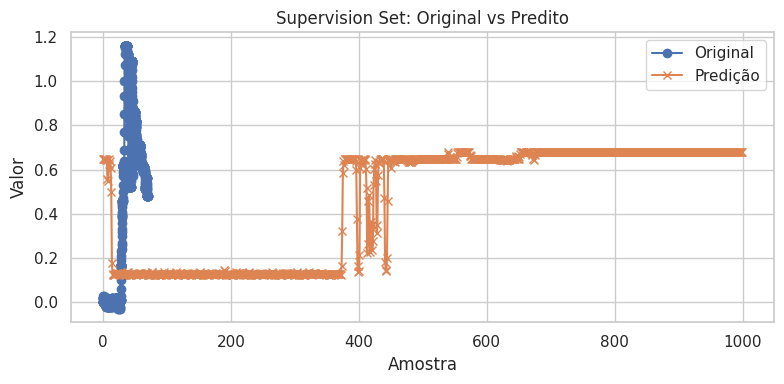

+++++++++++ [1] | 3 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


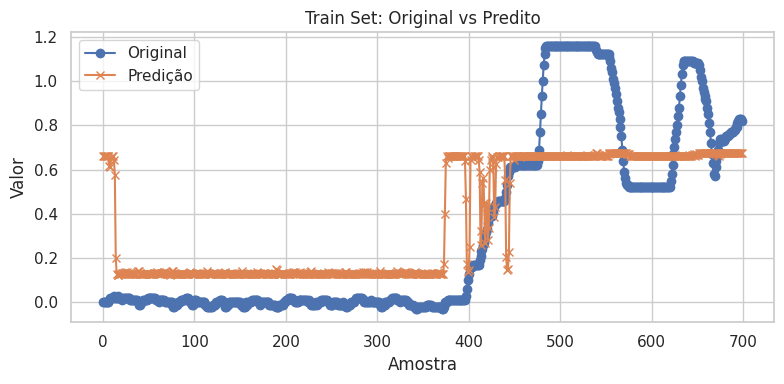

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


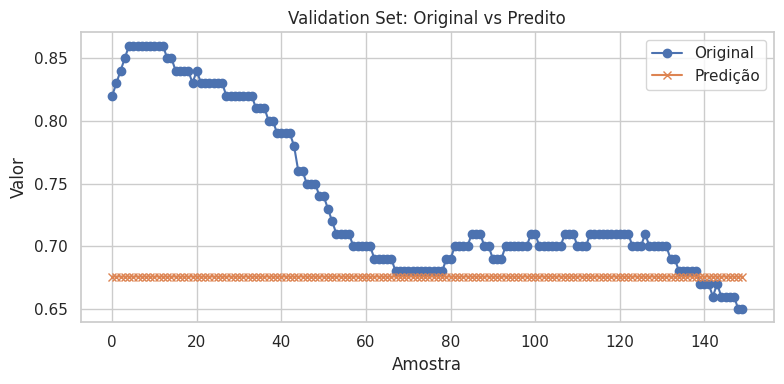

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


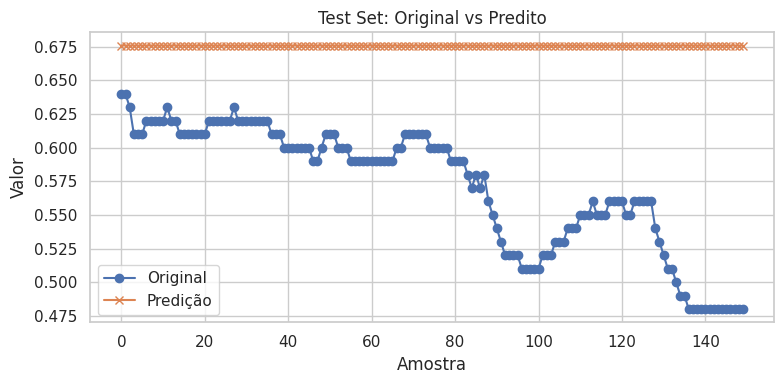

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


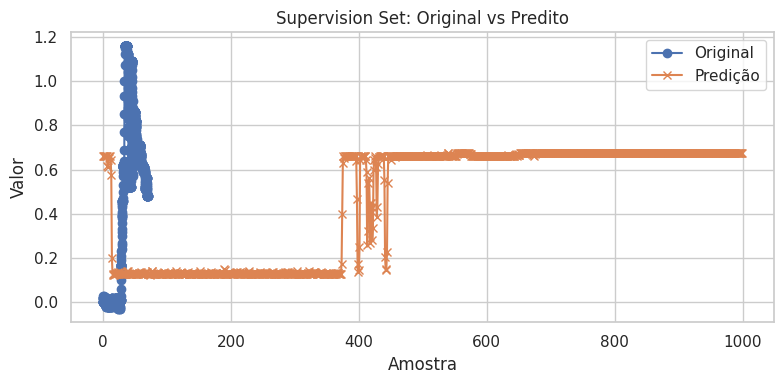

+++++++++++ [1] | 4 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


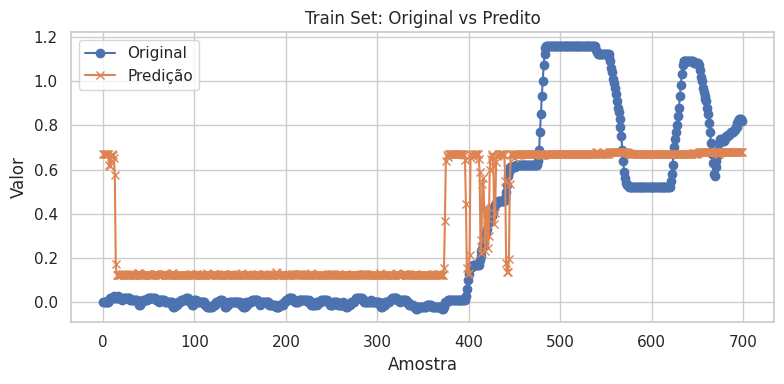

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


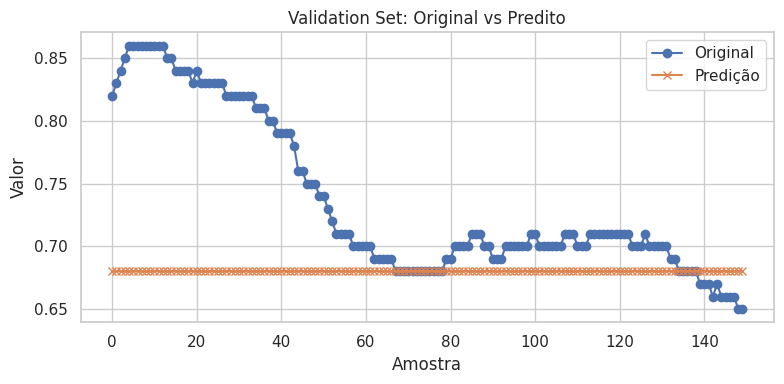

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


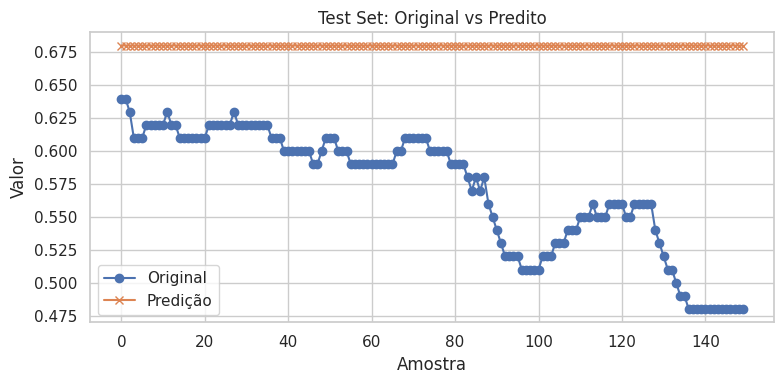

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


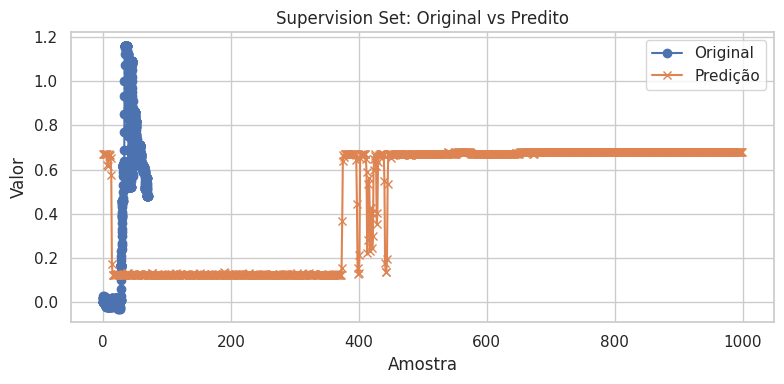

+++++++++++ [1] | 5 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


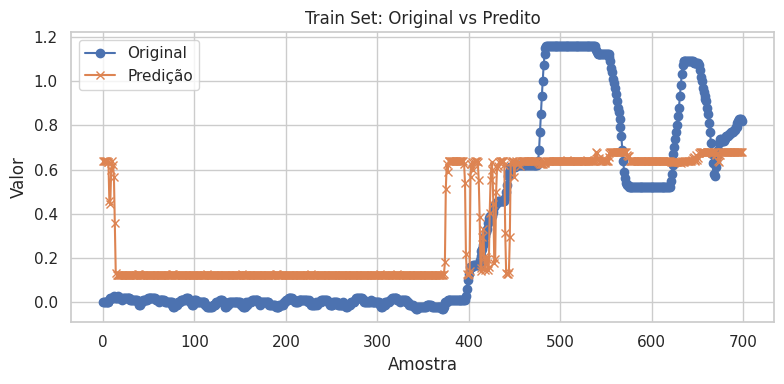

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


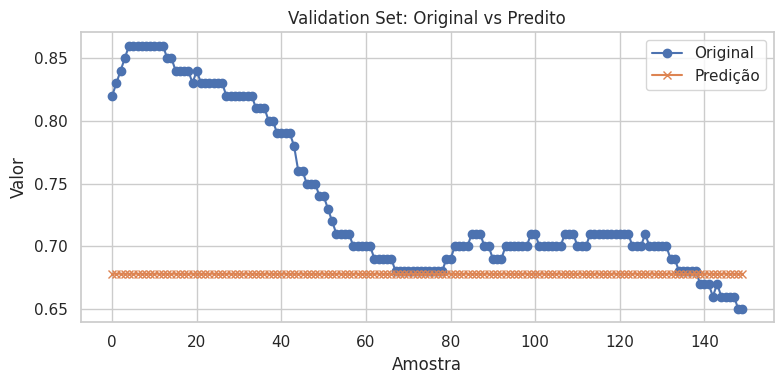

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


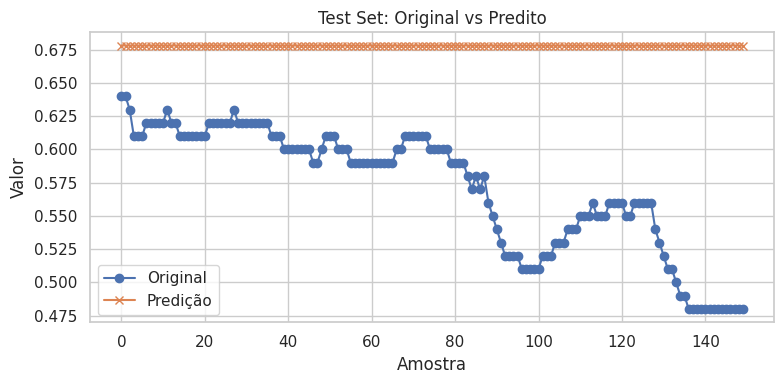

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


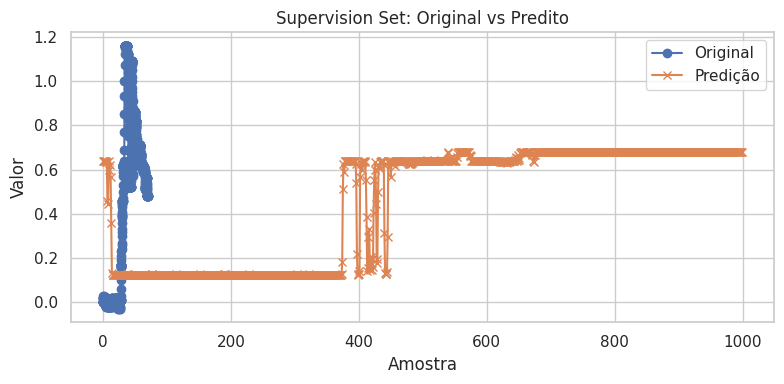

+++++++++++ [1] | 6 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


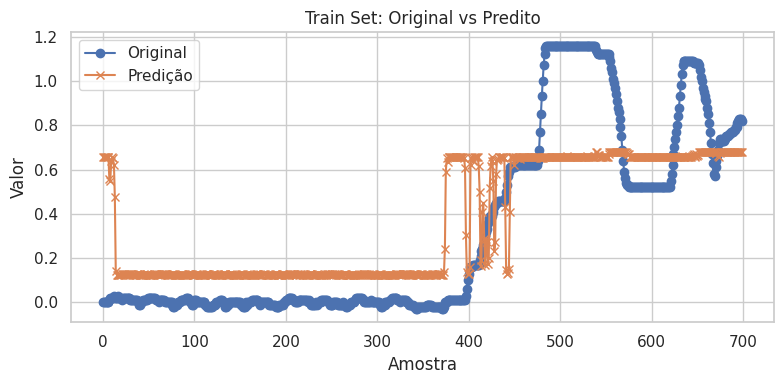

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


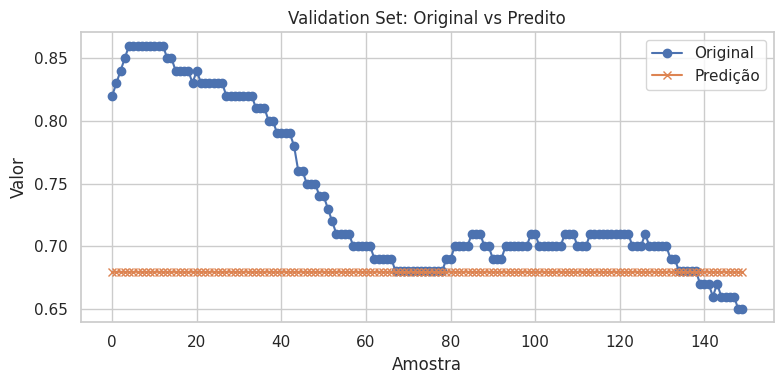

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


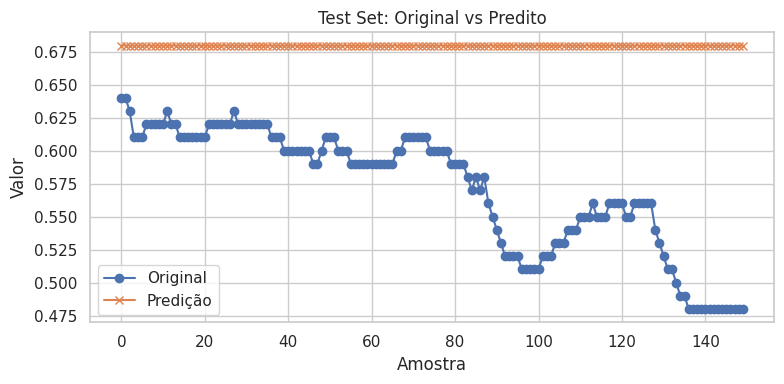

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


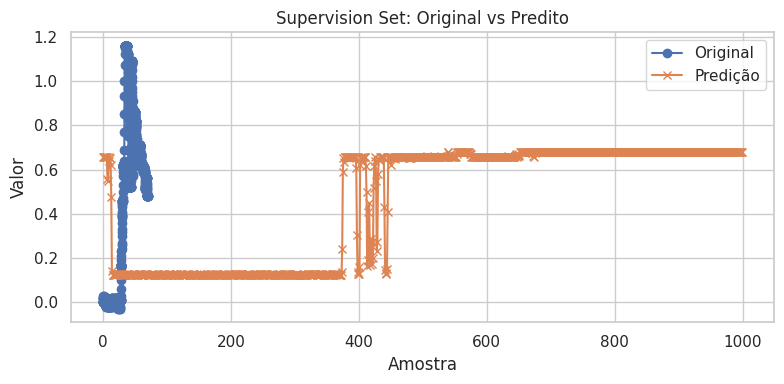

+++++++++++ [1] | 7 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


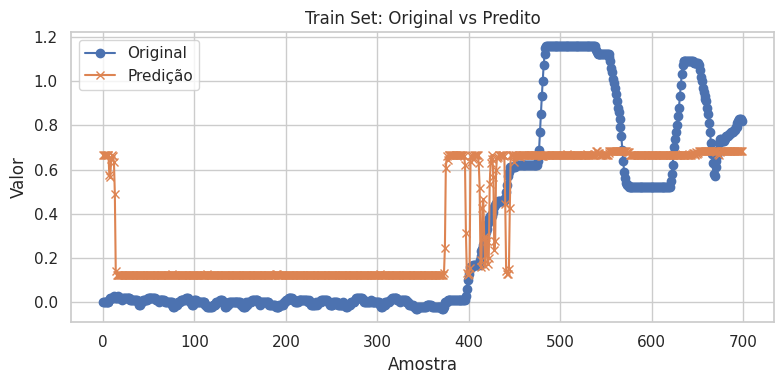

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


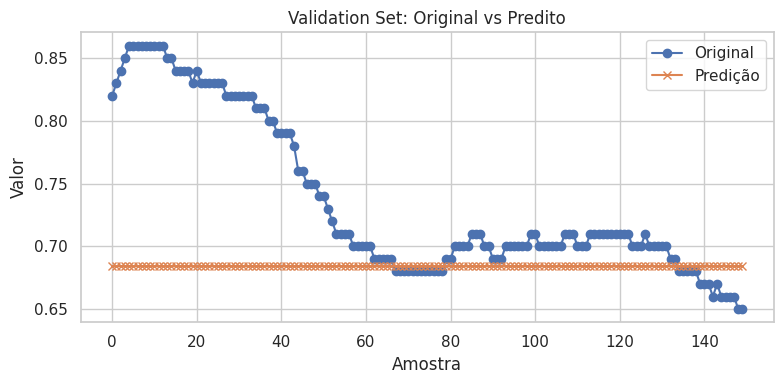

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


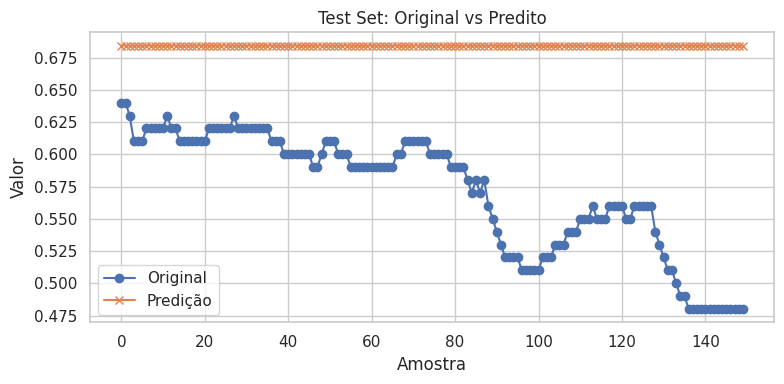

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


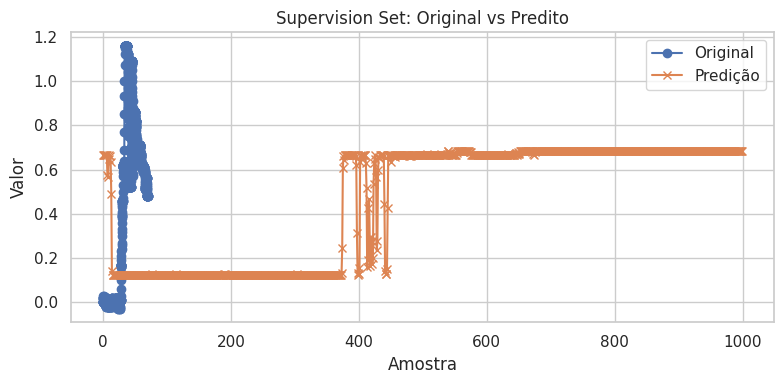

+++++++++++ [1] | 8 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


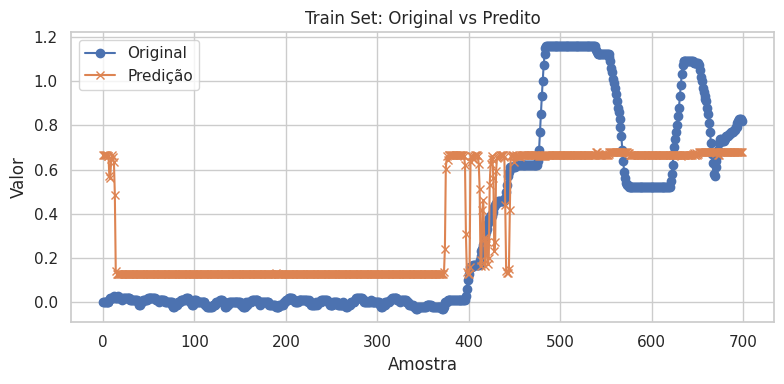

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


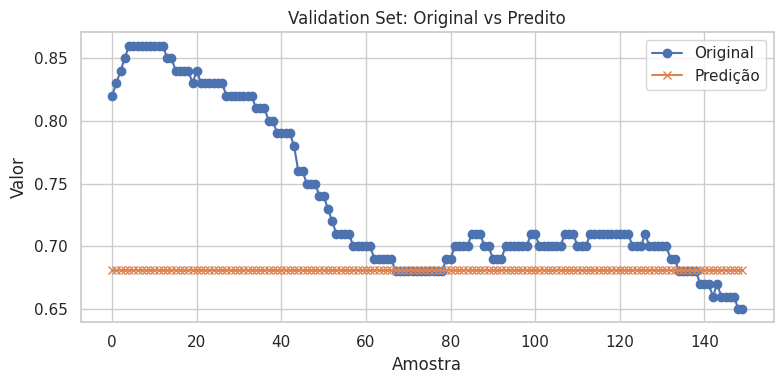

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


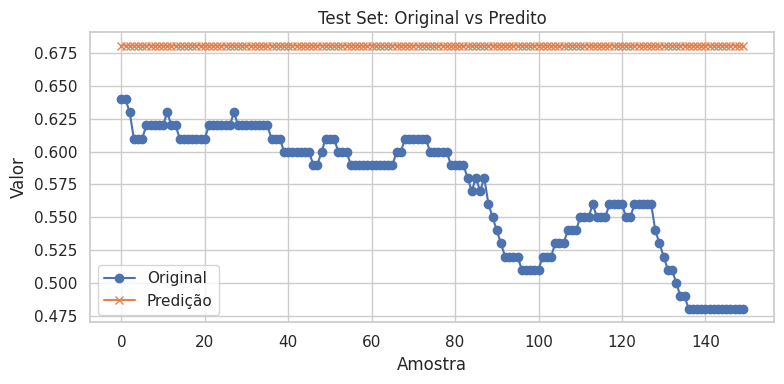

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


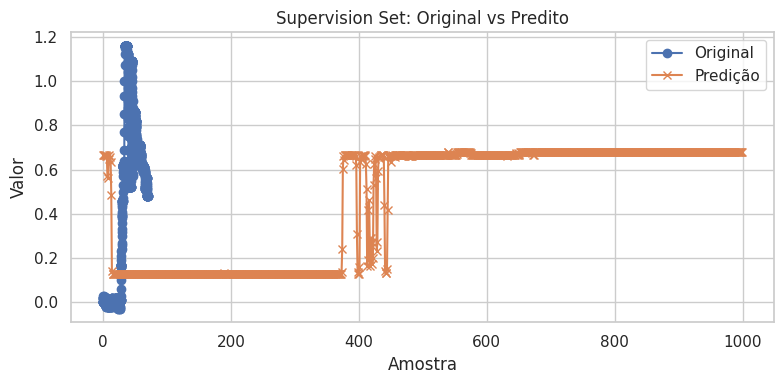

+++++++++++ [1] | 9 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


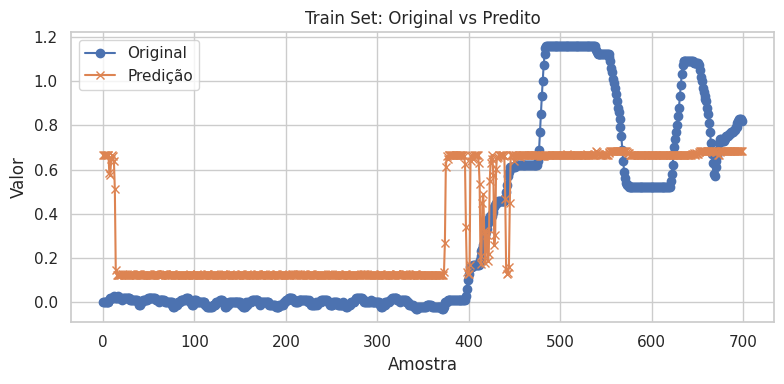

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


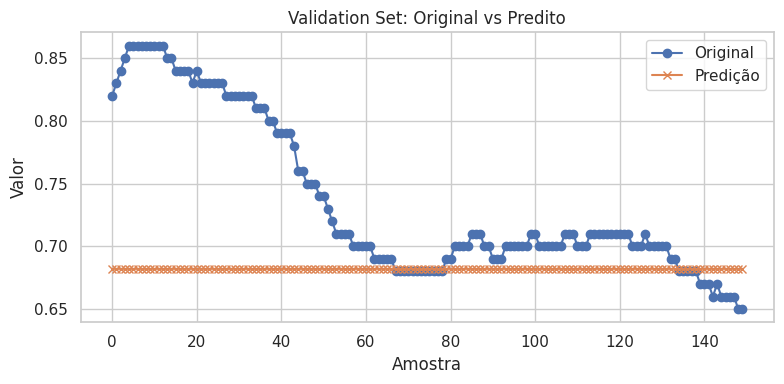

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


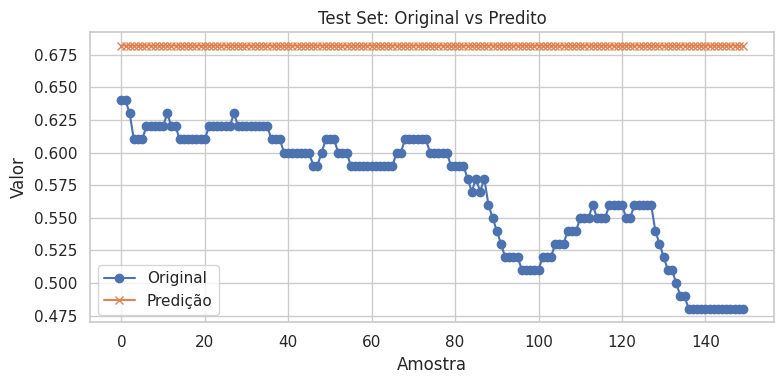

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


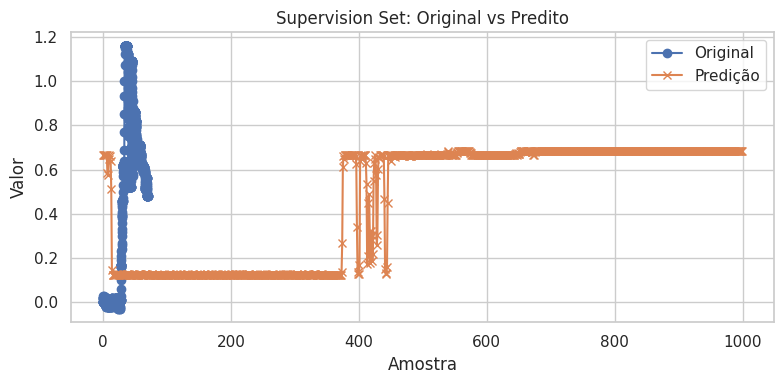

+++++++++++ [1] | 10 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


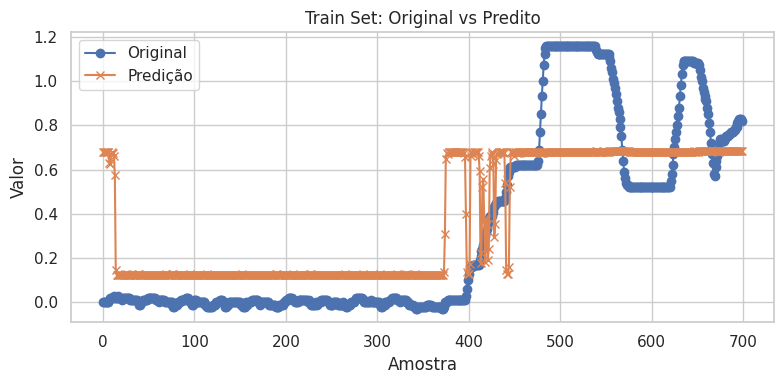

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


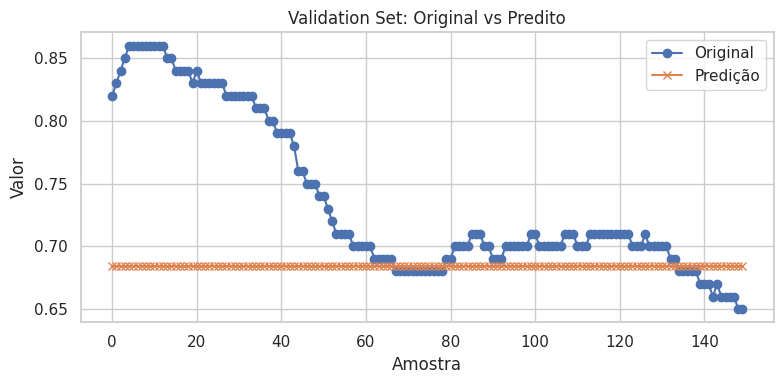

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


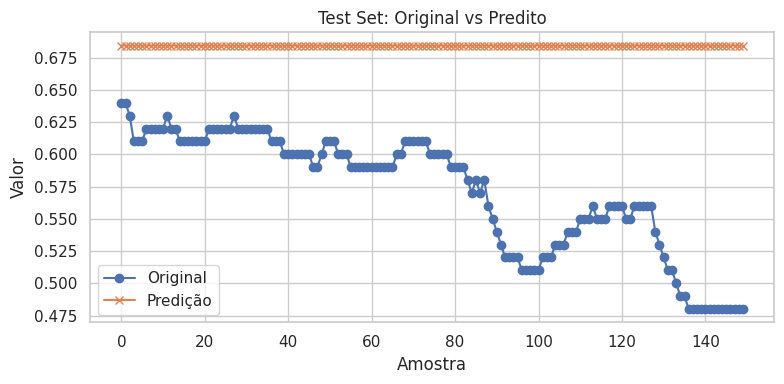

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


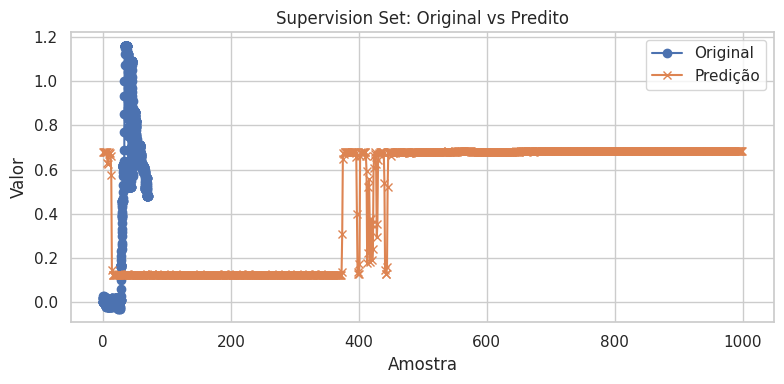

+++++++++++ [1] | 11 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


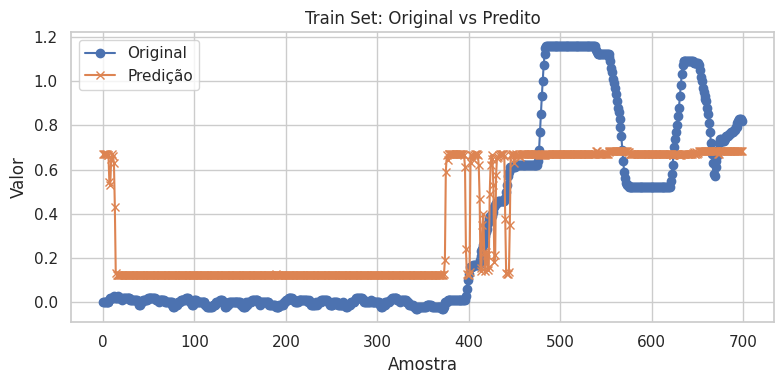

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


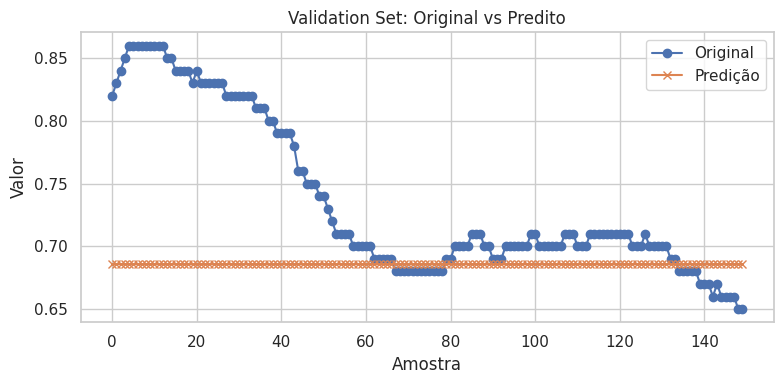

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


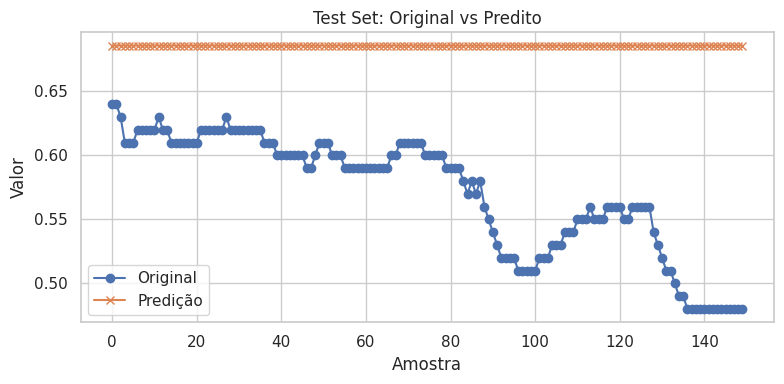

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


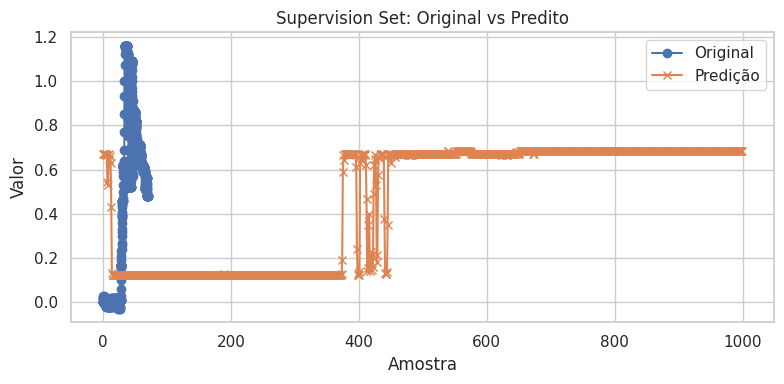

+++++++++++ [1] | 12 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


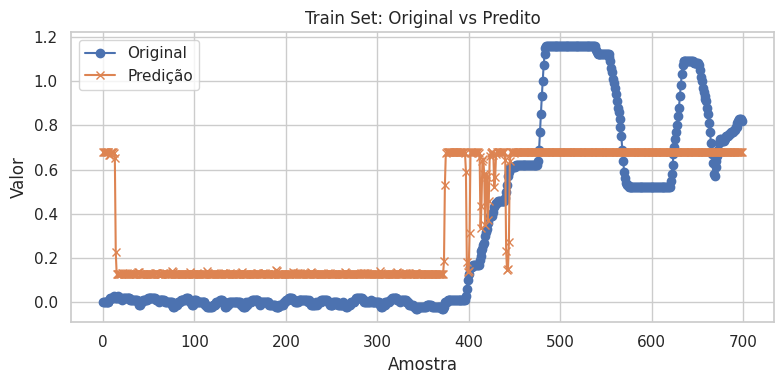

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


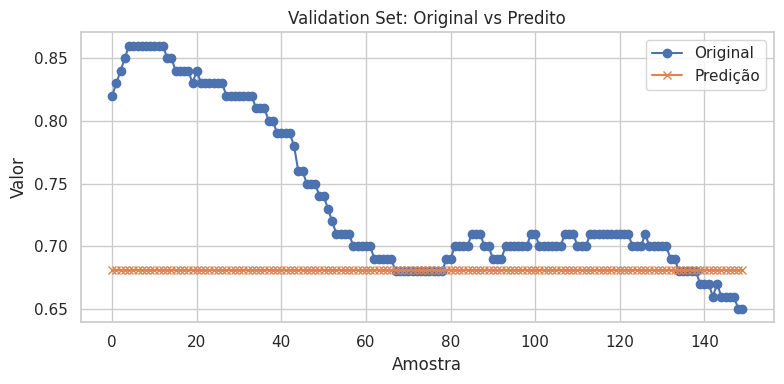

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


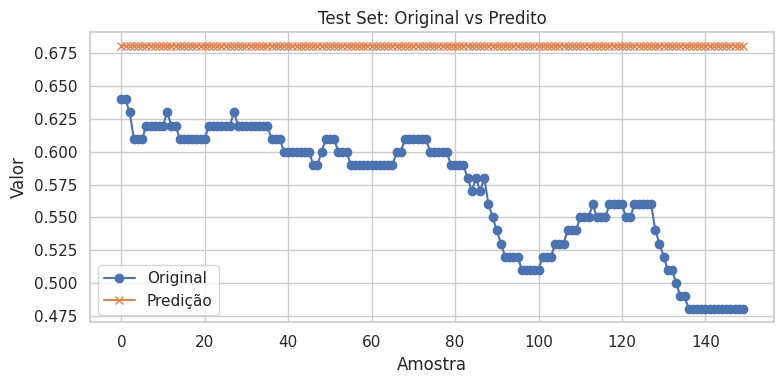

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


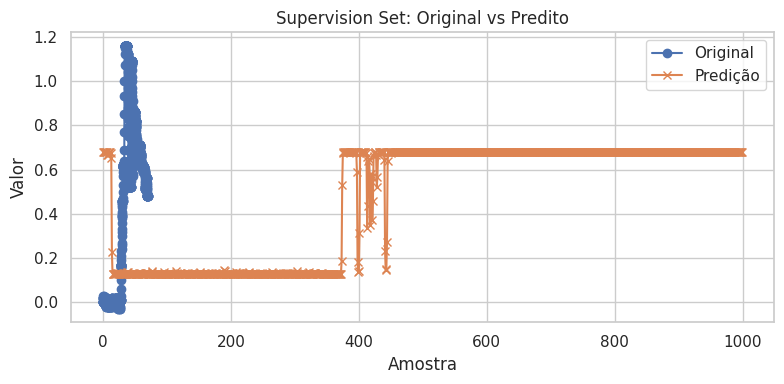

+++++++++++ [1] | 13 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


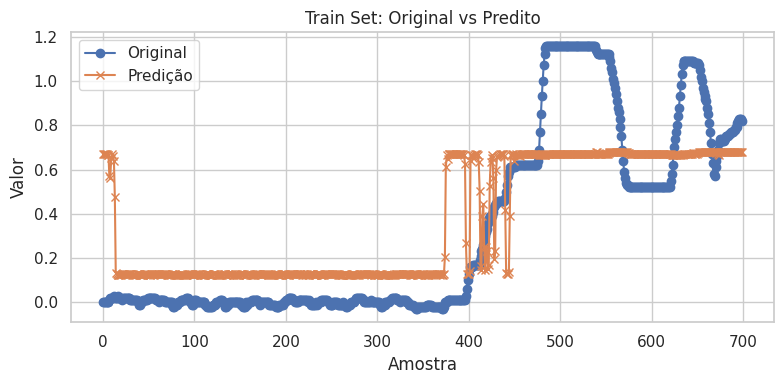

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


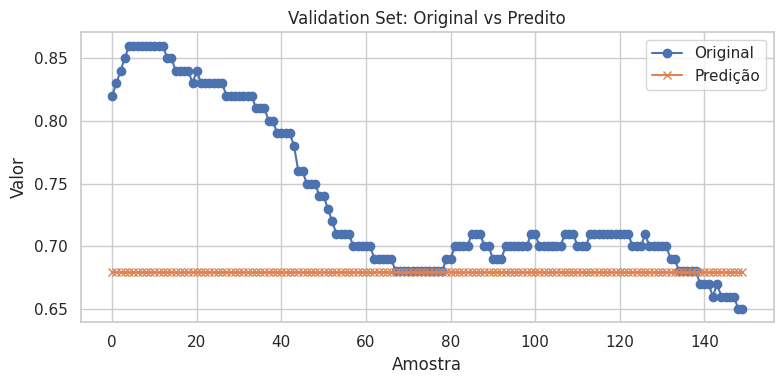

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


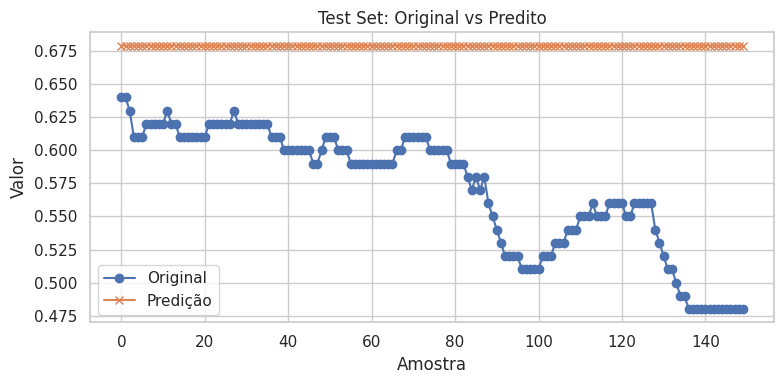

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


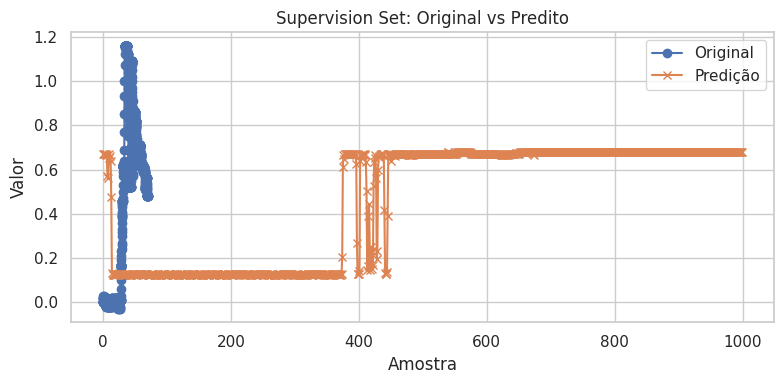

+++++++++++ [1] | 14 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


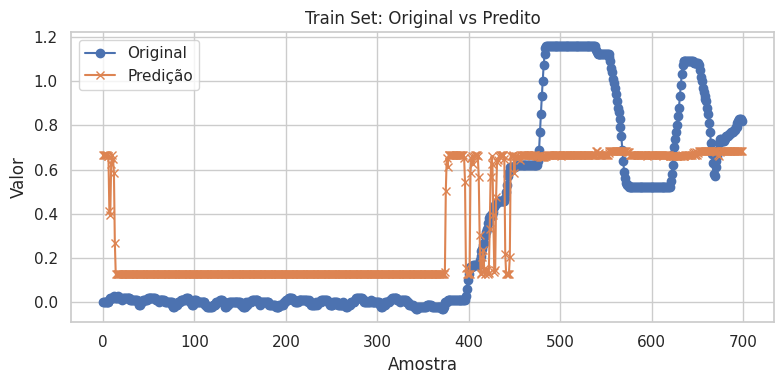

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


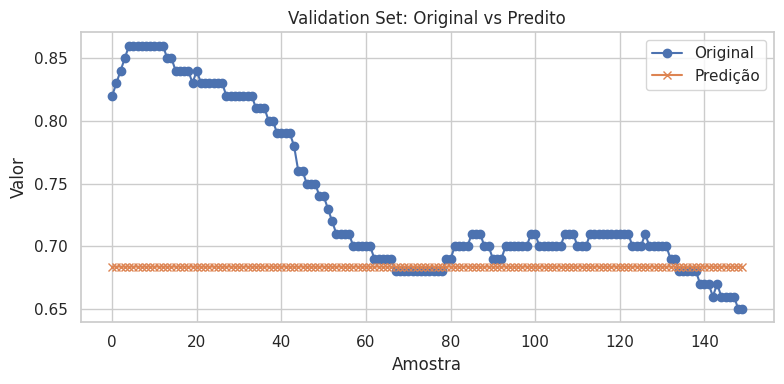

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


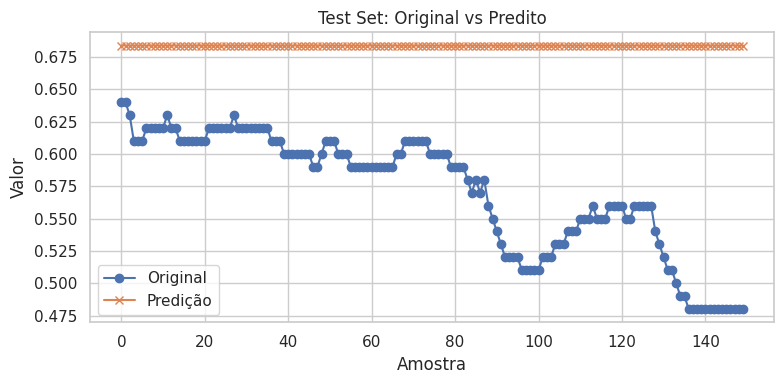

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


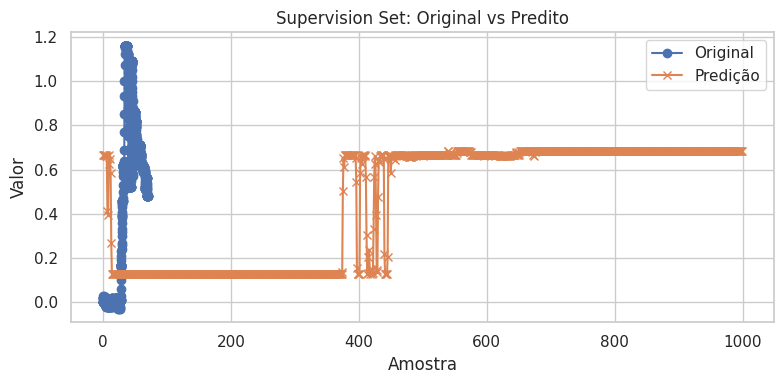

+++++++++++ [1] | 15 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


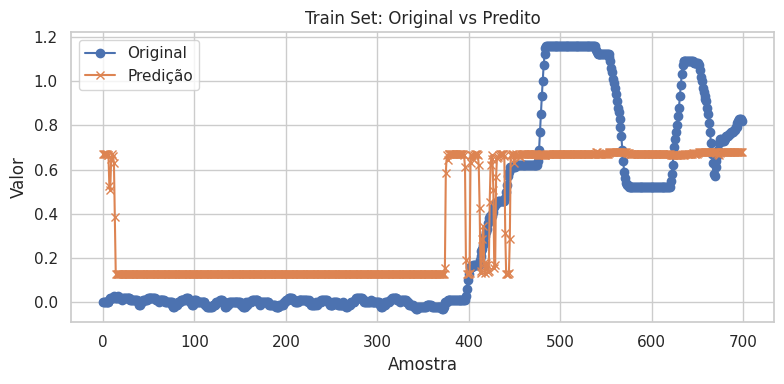

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


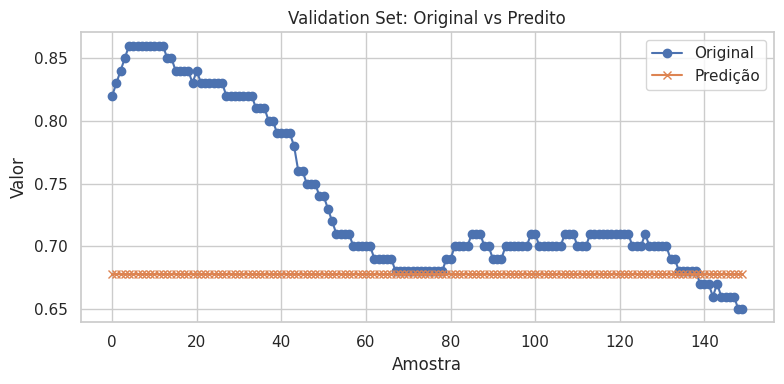

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


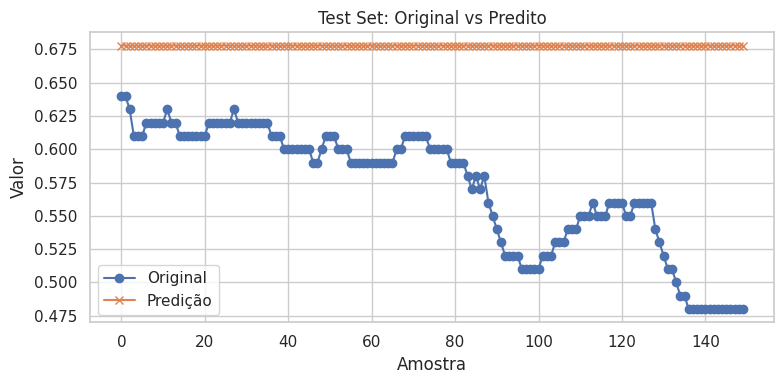

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


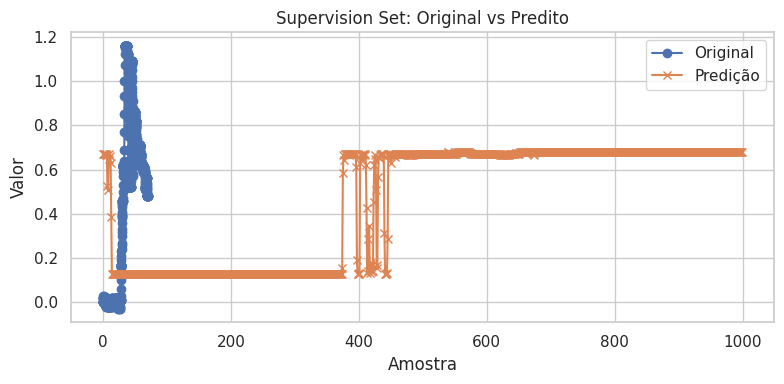

+++++++++++ [1] | 16 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


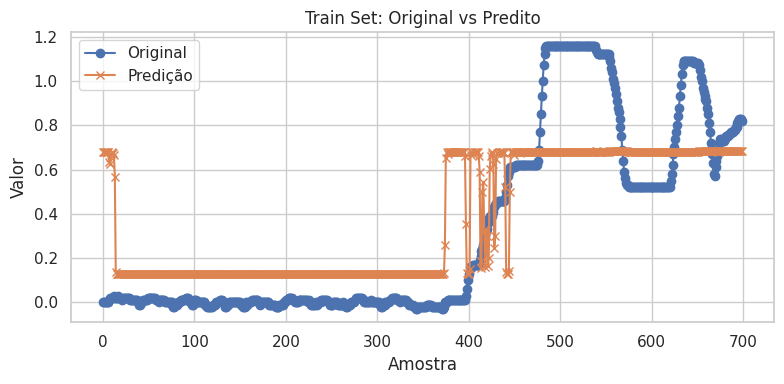

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


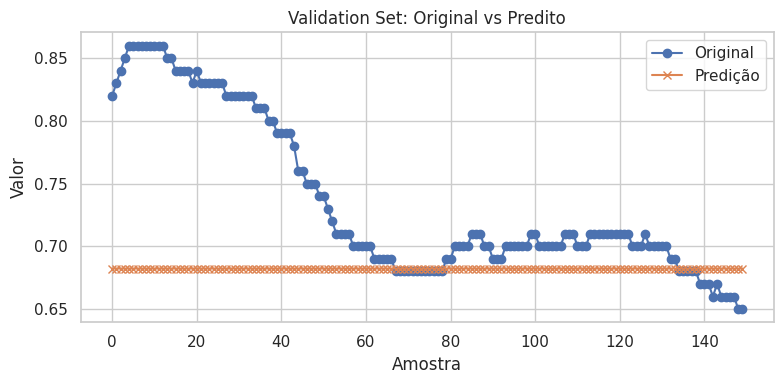

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


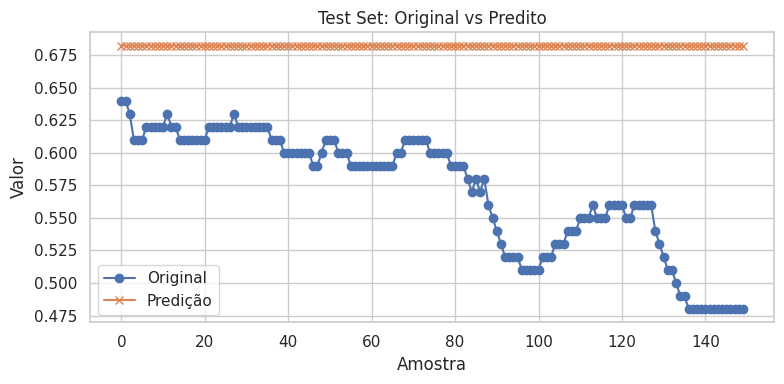

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


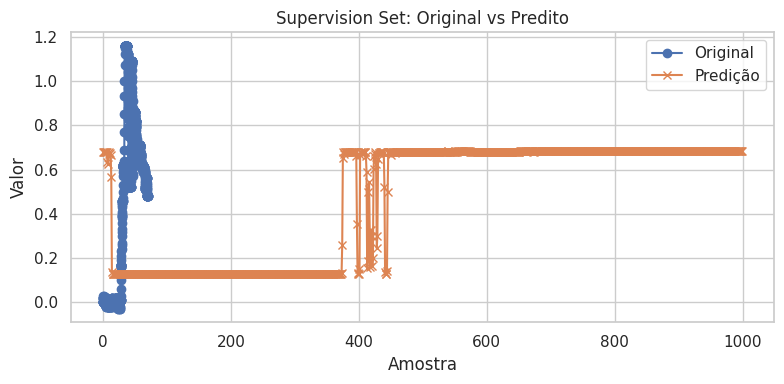

+++++++++++ [1] | 17 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


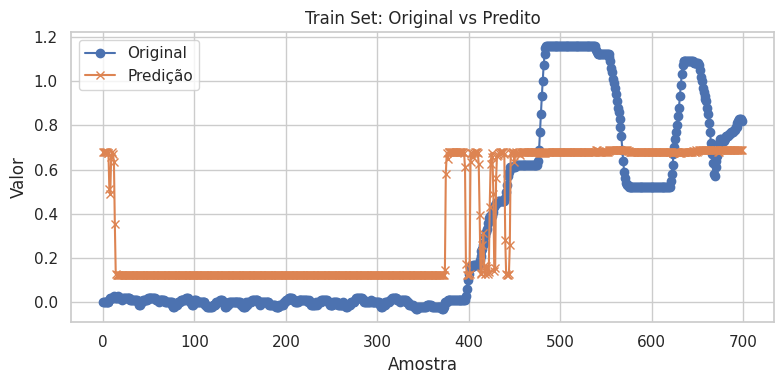

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


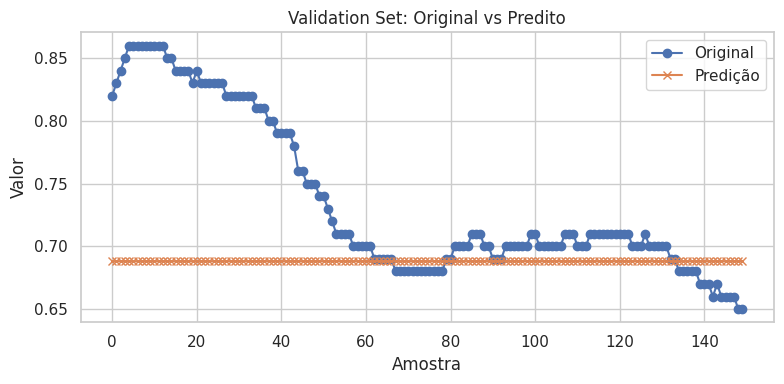

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


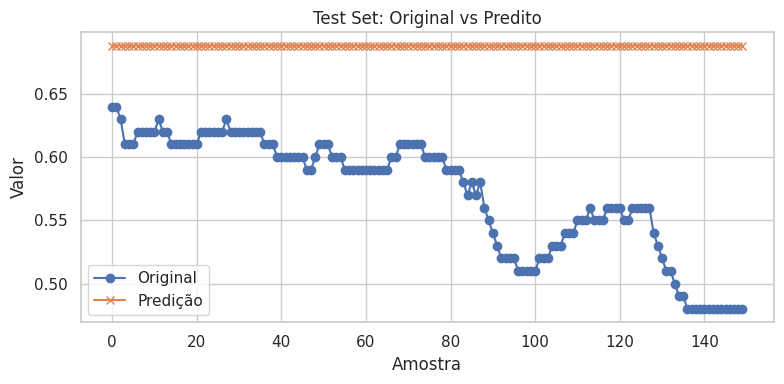

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


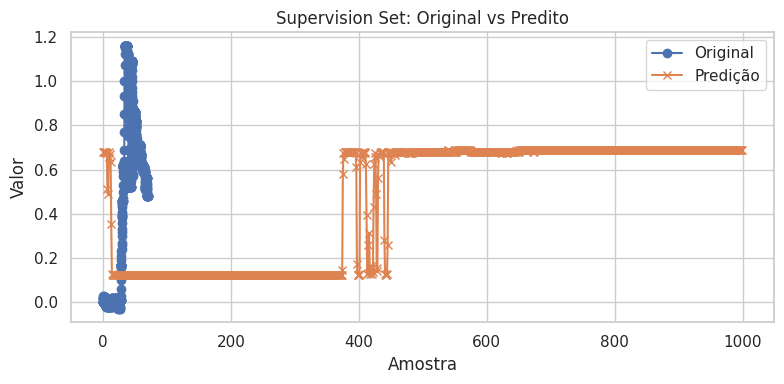

+++++++++++ [1] | 18 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


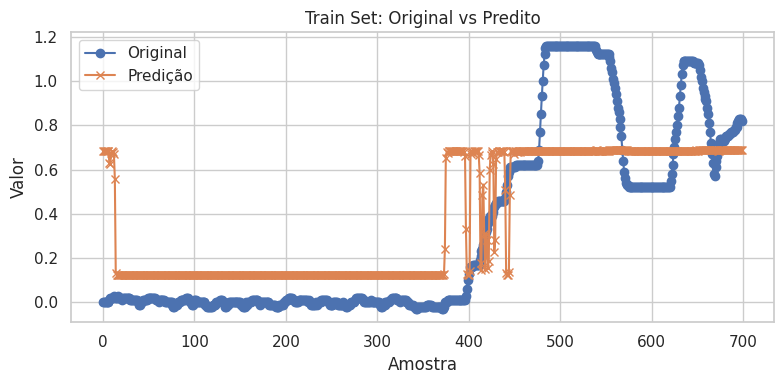

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


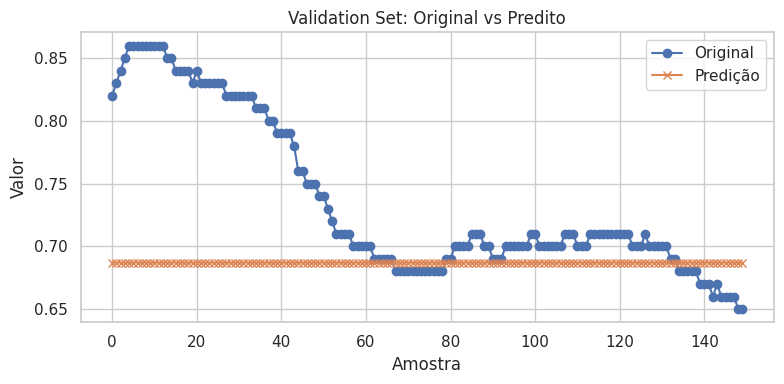

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


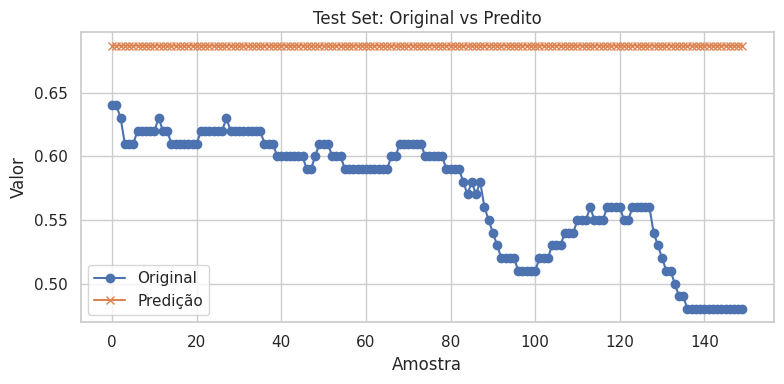

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


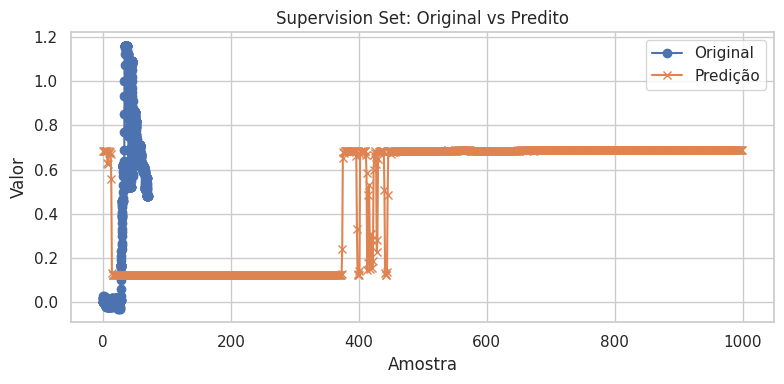

+++++++++++ [1] | 19 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


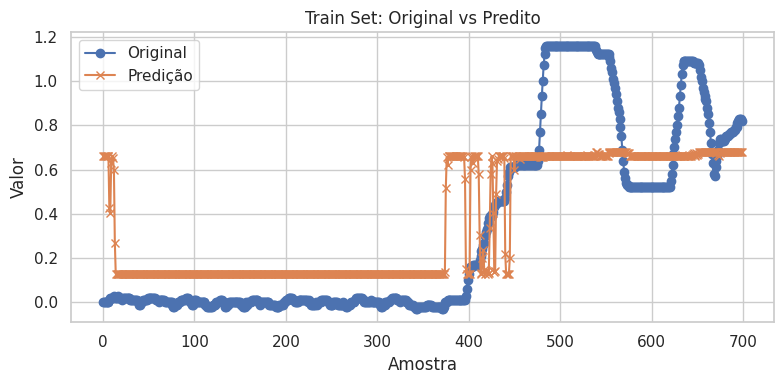

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


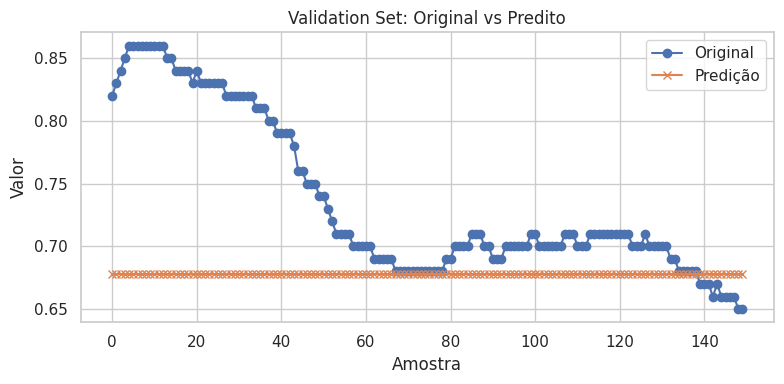

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


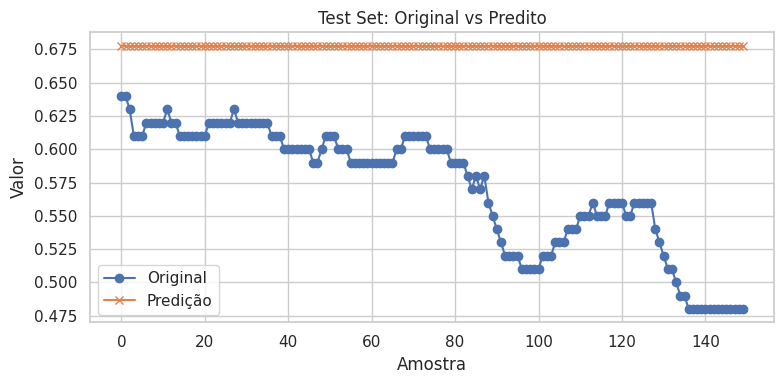

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


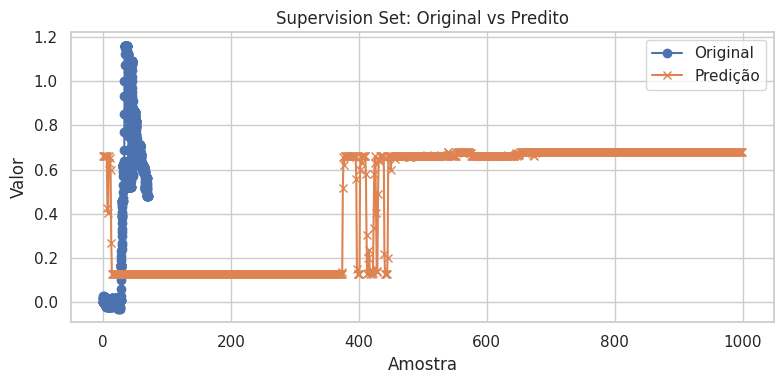

+++++++++++ [1] | 20 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


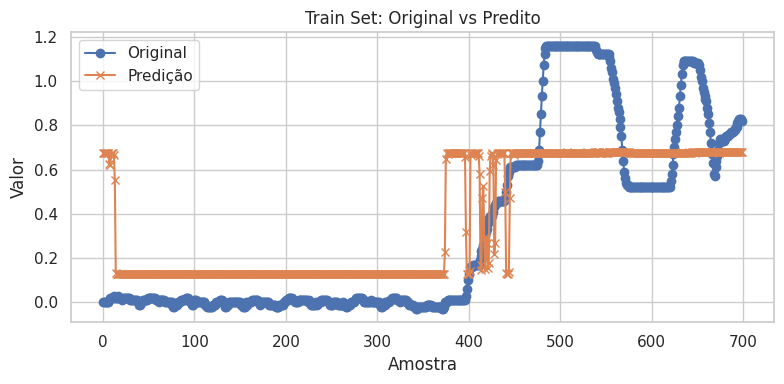

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


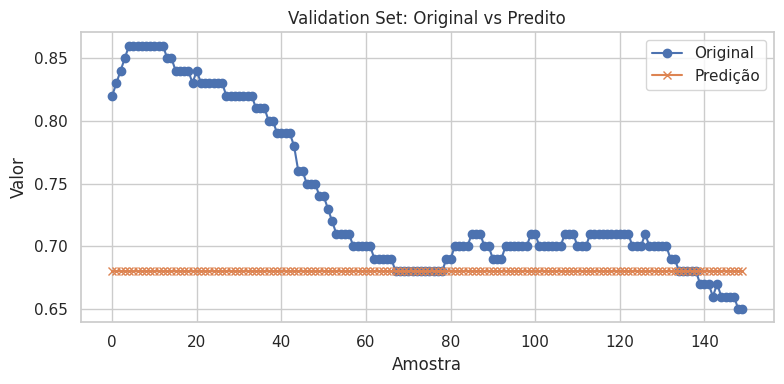

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


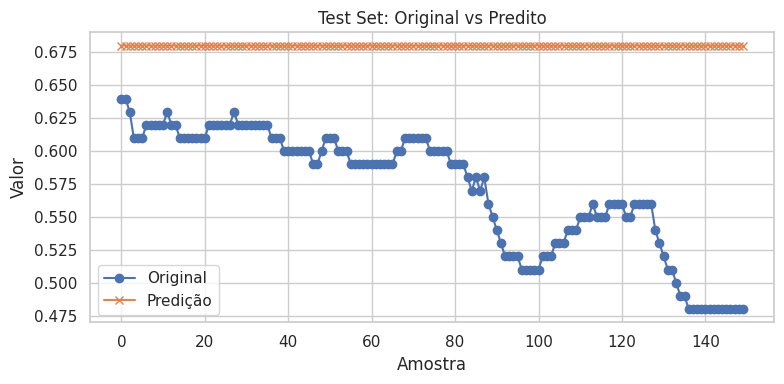

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


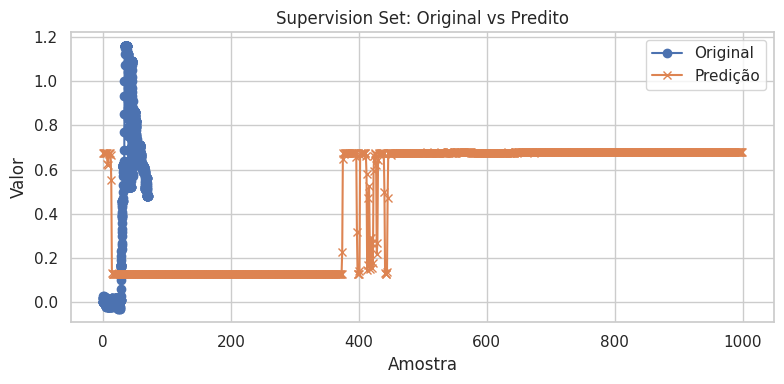

+++++++++++ [1] | 21 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


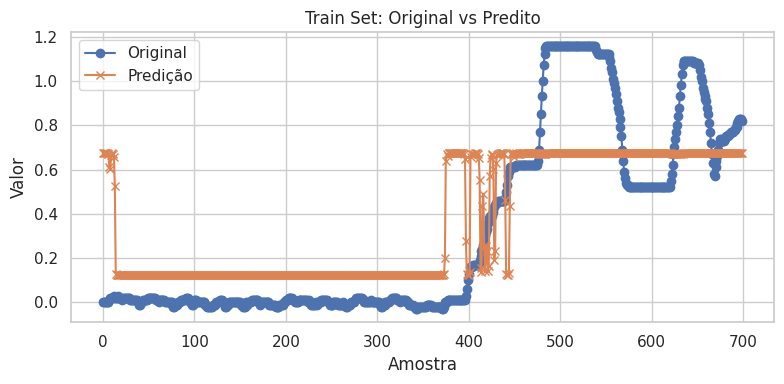

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


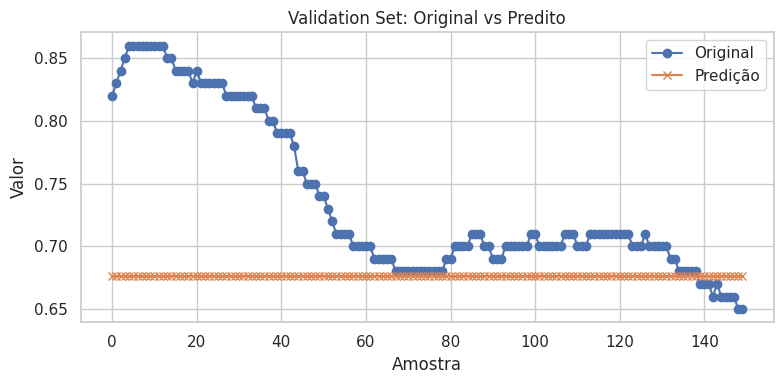

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


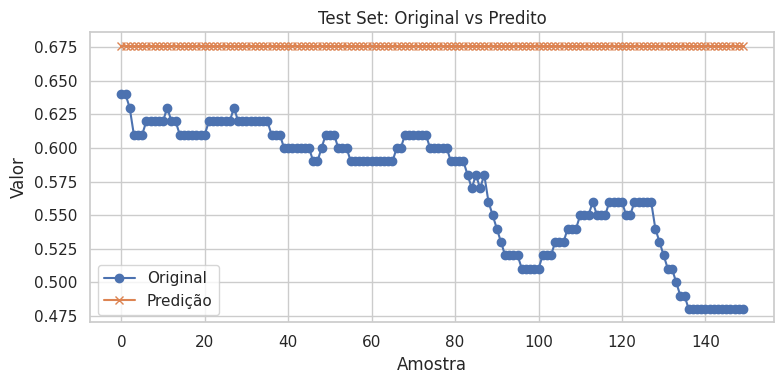

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


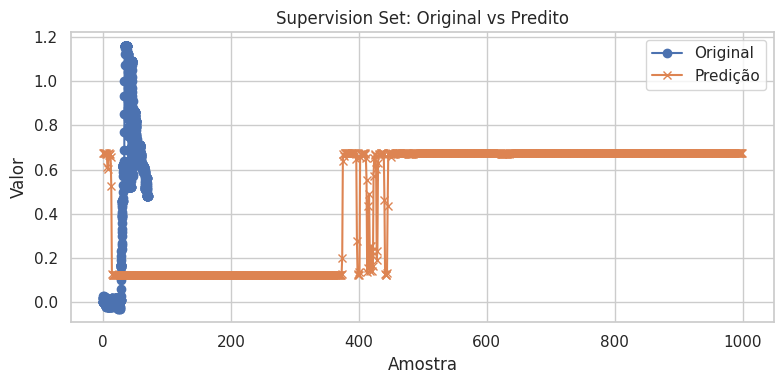

+++++++++++ [1] | 22 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


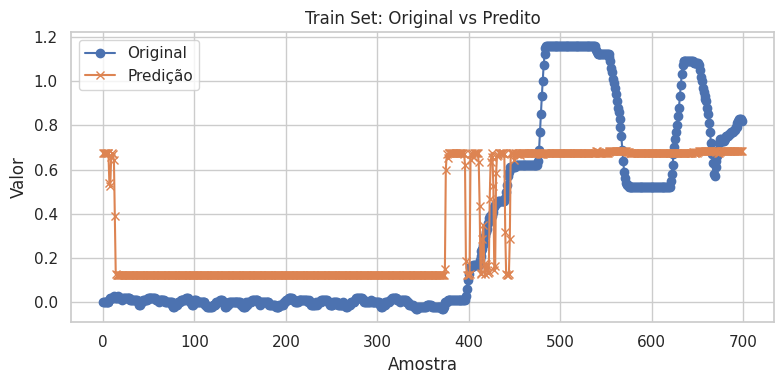

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


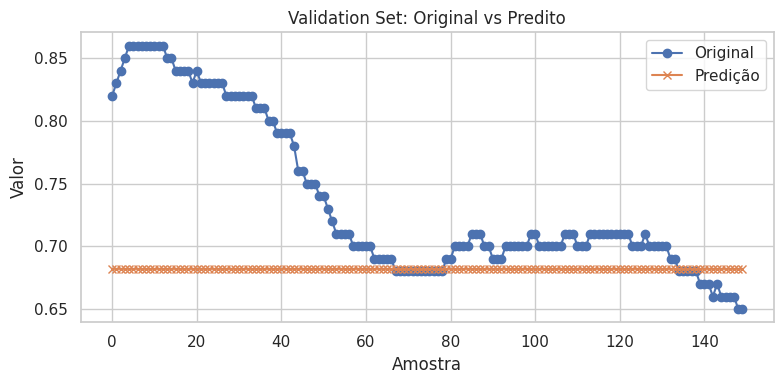

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


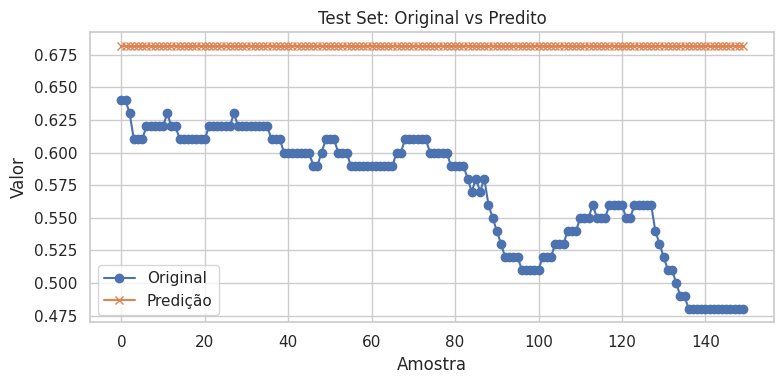

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


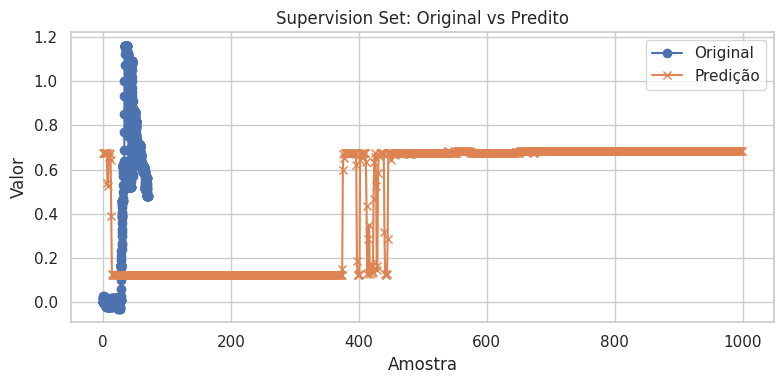

+++++++++++ [1] | 23 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


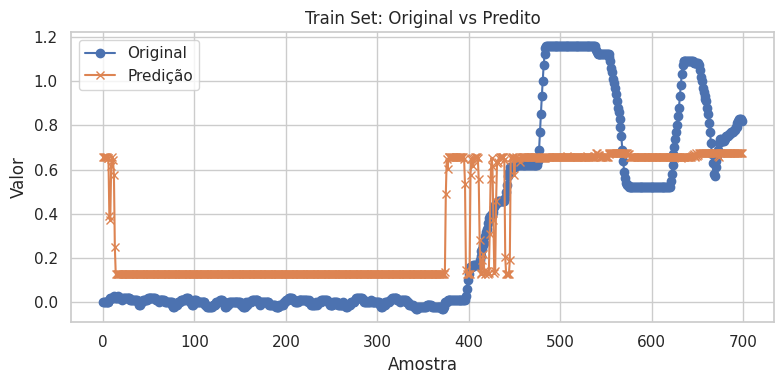

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


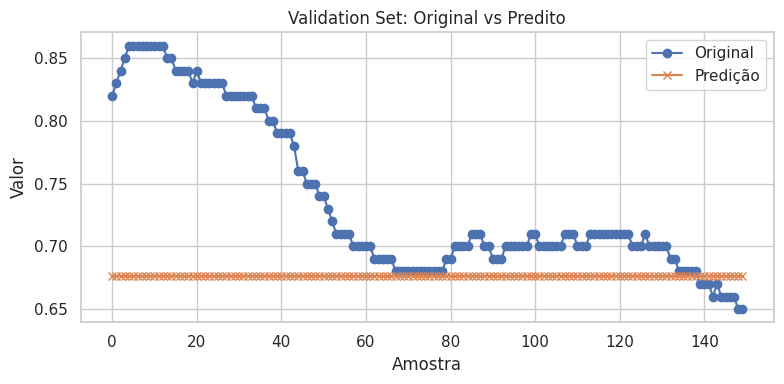

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


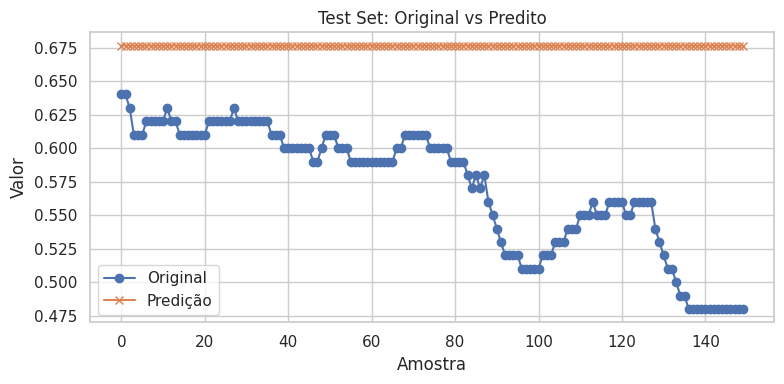

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


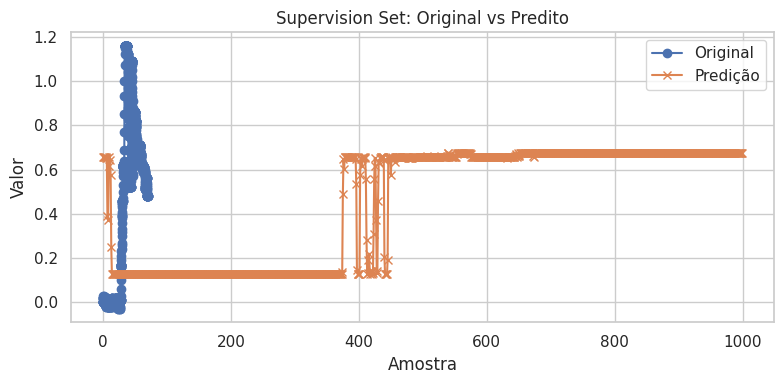

+++++++++++ [1] | 24 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


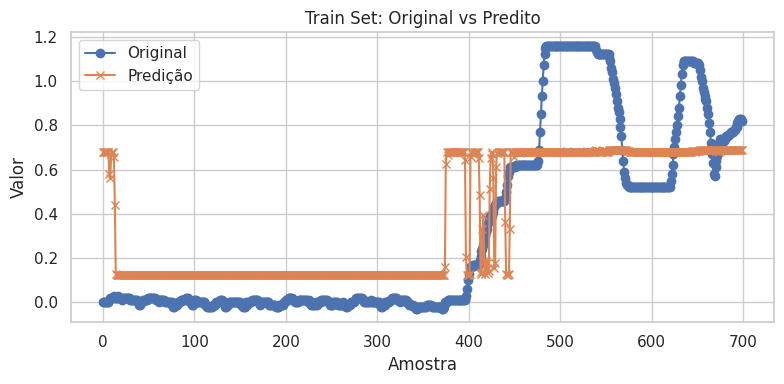

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


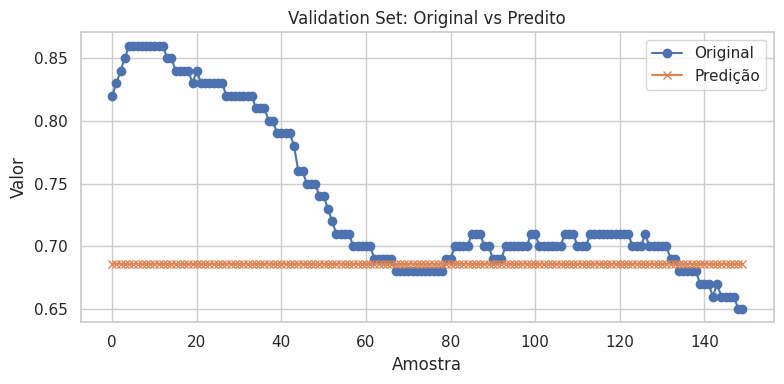

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


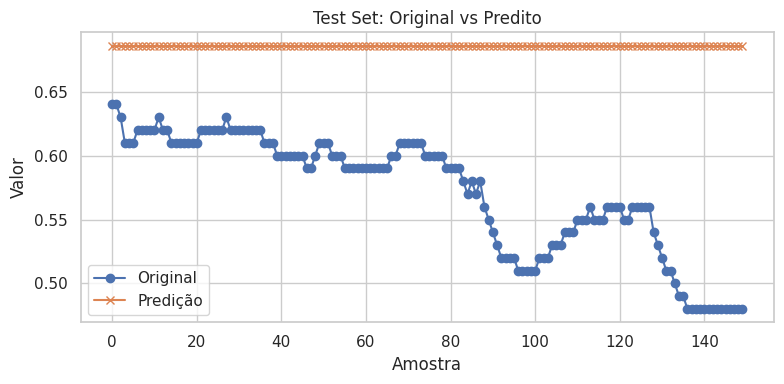

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


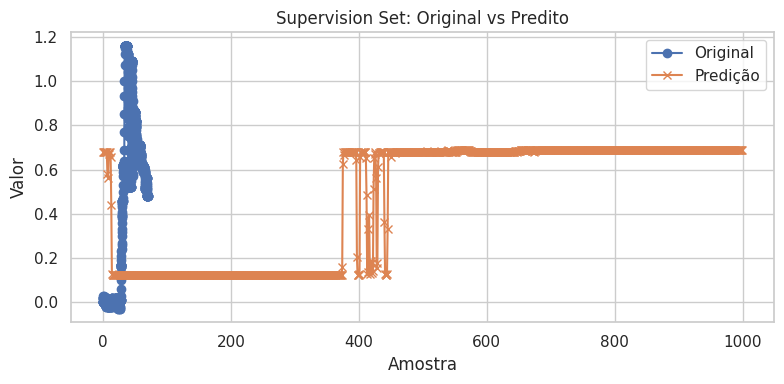

+++++++++++ [1] | 25 ++++++++++++++++++
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


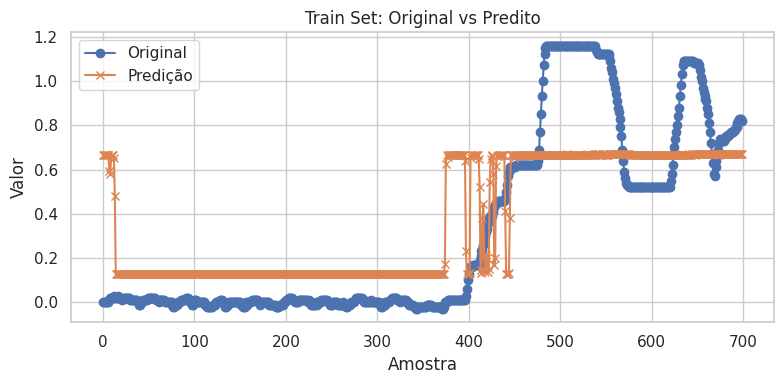

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


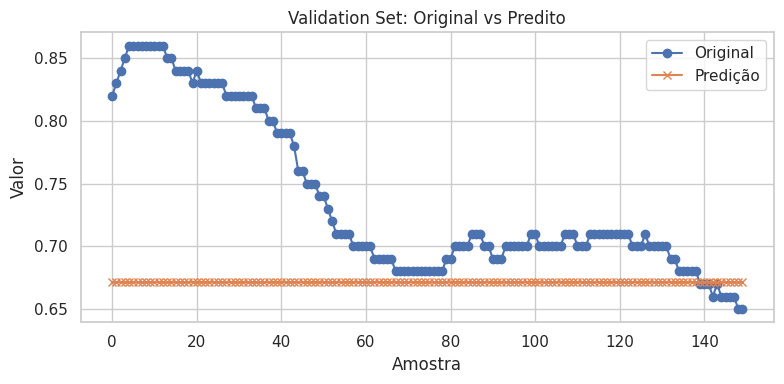

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


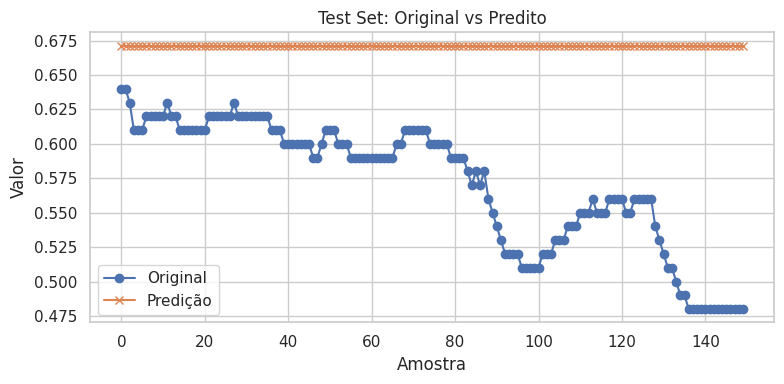

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


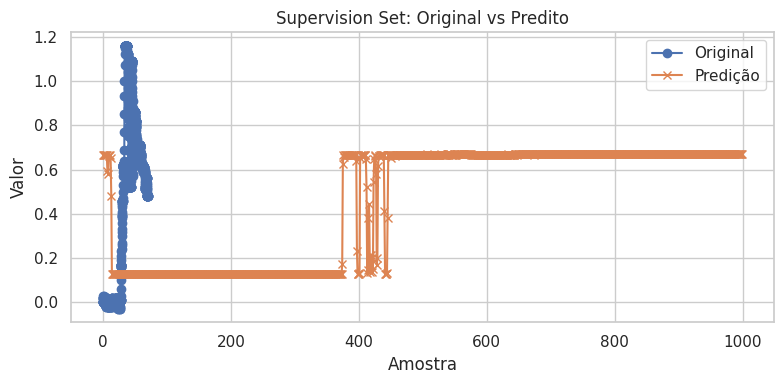

,r2,r2_sup,r2_test,r2_val,mse,mse_sup,mse_test,mse_val
model_1_13,0.623832,0.663927,-5.837768,-0.678825,0.068870,0.051452,0.014806,0.006817
model_1_22,0.622143,0.663269,-5.100545,-0.881861,0.069179,0.051553,0.013210,0.007641
model_1_18,0.621161,0.662315,-5.241877,-0.839754,0.069359,0.051699,0.013516,0.007470
model_1_16,0.622341,0.662130,-6.298494,-0.570938,0.069143,0.051727,0.015804,0.006379
model_1_10,0.621148,0.661431,-6.052389,-0.626922,0.069361,0.051834,0.015271,0.006606
model_1_4,0.619635,0.661017,-5.262224,-0.834113,0.069638,0.051898,0.013560,0.007448
model_1_21,0.619949,0.660881,-5.652485,-0.726129,0.069581,0.051919,0.014405,0.007009
model_1_6,0.619666,0.660384,-5.885844,-0.667020,0.069632,0.051995,0.014910,0.006769
model_1_23,0.619069,0.659664,-6.074709,-0.621663,0.069742,0.052105,0.015319,0.006585
model_1_5,0.617882,0.659401,-5.412875,-0.791076,0.069959,0.052145,0.013886,0.007273


DataFrame salvo em ./results/metrics_1


In [8]:
tester = TrainWithSmallDataset(Dataset=data,
                                run_times=25,
                                dataset_run_times=10)
tester.Evaluate(sort_by='mse_sup',
            boundarie = 0.5,
            hidden_sizes = [[2]],
            regularizers=[0.02],
            learning_rate=[0.01])